# Category-level CF-KL Distribution (Math-Correct + Logic-Correct)

This notebook redraws the category-level CF-KL distribution by combining Math-Correct and Logic-Correct in one figure.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

DATA_ROOT = Path(r"d:\Files\UW-M\26_1_spring\CS639\prj\proposal_math+logic")

ANALYSIS_PATHS = {
    "Math-Correct": DATA_ROOT / "math" / "problem_0" / "im_CF_kl" / "correct_base_solution" / "analysis_results.json",
    "Logic-Correct": DATA_ROOT / "logic" / "problem_0" / "im_CF_kl" / "correct_base_solution" / "analysis_results.json",
}

OUTPUT_FIG_PATH = DATA_ROOT / "Category-level_CF-KL_distribution_Math-Logic-Correct.png"

In [2]:
def _to_display_tag(tag: str) -> str:
    return " ".join(word.capitalize() for word in str(tag).split("_"))


def load_cf_kl_records(analysis_path: Path, split_name: str) -> list[dict]:
    payload = json.loads(analysis_path.read_text(encoding="utf-8"))
    if isinstance(payload, dict):
        payload = [payload]

    records = []
    for problem_result in payload:
        for chunk in problem_result.get("labeled_chunks", []):
            cf_kl = chunk.get("counterfactual_importance_kl")
            if cf_kl is None:
                continue

            for raw_tag in (chunk.get("function_tags") or []):
                tag = str(raw_tag).strip()
                if not tag or tag.lower() == "unknown":
                    continue

                records.append({
                    "Split": split_name,
                    "Category": _to_display_tag(tag),
                    "CF_KL_x100": float(cf_kl) * 100.0,
                })
    return records


all_records = []
for split_name, analysis_path in ANALYSIS_PATHS.items():
    if not analysis_path.exists():
        raise FileNotFoundError(f"Missing file: {analysis_path}")
    all_records.extend(load_cf_kl_records(analysis_path, split_name))

df = pd.DataFrame(all_records)
if df.empty:
    raise ValueError("No valid CF-KL records found.")

category_order = (
    df.groupby("Category", as_index=False)["CF_KL_x100"]
      .mean()
      .sort_values("CF_KL_x100", ascending=False)["Category"]
      .tolist()
)

summary = (
    df.groupby(["Split", "Category"]) ["CF_KL_x100"]
      .agg(["count", "mean"])
      .round(2)
      .sort_values(["Split", "mean"], ascending=[True, False])
)
summary


count   mean
Split         Category                            
Logic-Correct Plan Generation            19  32.24
              Uncertainty Management    106  21.94
              Result Consolidation       30  18.57
              Active Computation        152  16.95
              Fact Retrieval             31   9.82
              Self Checking               6   8.28
              Problem Setup              11   5.66
Math-Correct  Plan Generation            15  71.48
              Problem Setup               3  35.14
              Fact Retrieval              7  19.38
              Active Computation         89  15.59
              Uncertainty Management     27   8.32
              Final Answer Emission       1   0.00
              Result Consolidation        1   0.00
              Self Checking               5   0.00

C:\Users\EvaSong\AppData\Local\Temp\ipykernel_10736\2652395277.py:10: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


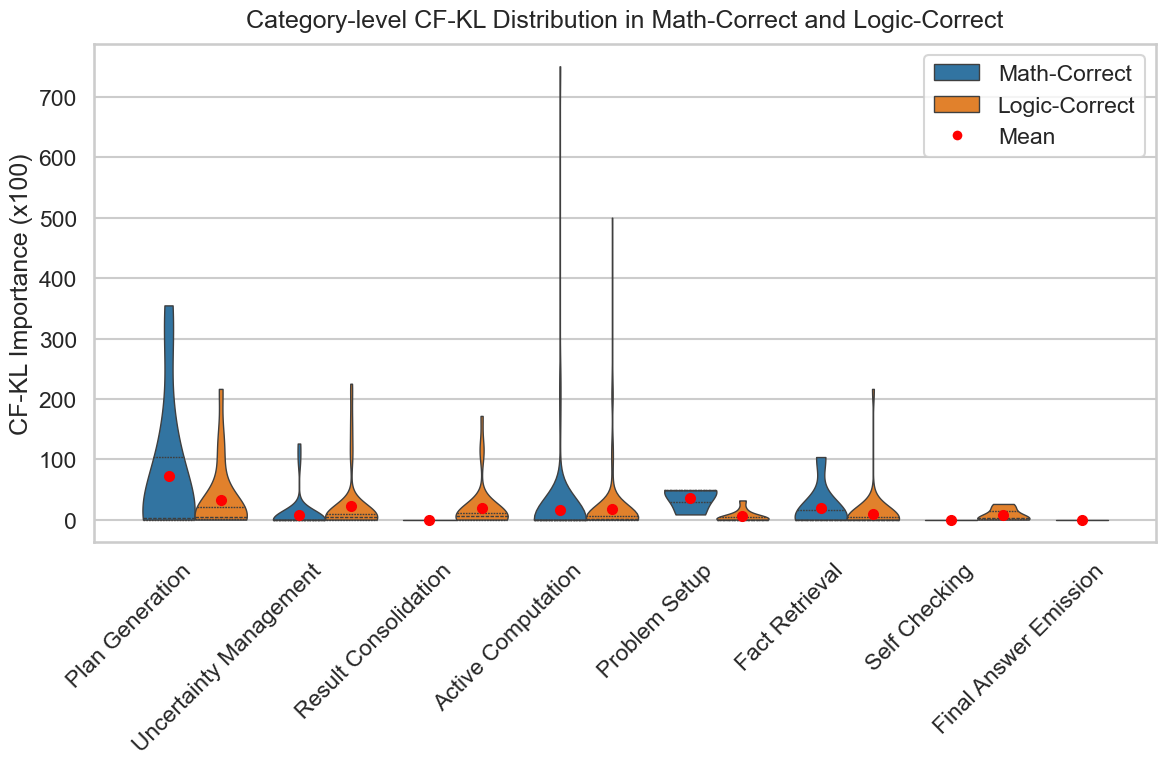

Saved figure to: d:\Files\UW-M\26_1_spring\CS639\prj\proposal_math+logic\Category-level_CF-KL_distribution_Math-Logic-Correct.png


In [3]:
sns.set_theme(style="whitegrid", context="talk")

hue_order = ["Math-Correct", "Logic-Correct"]
palette = {
    "Math-Correct": "#1f77b4",
    "Logic-Correct": "#ff7f0e",
}

fig, ax = plt.subplots(figsize=(12, 8))
sns.violinplot(
    data=df,
    x="Category",
    y="CF_KL_x100",
    hue="Split",
    order=category_order,
    hue_order=hue_order,
    palette=palette,
    inner="quartile",
    cut=0,
    scale="width",
    linewidth=1,
    ax=ax,
)

mean_df = (
    df.groupby(["Category", "Split"], as_index=False)["CF_KL_x100"]
      .mean()
)

n_hue = len(hue_order)
width = 0.8
offsets = np.linspace(-width / 2 + width / (2 * n_hue), width / 2 - width / (2 * n_hue), n_hue)

for i, category in enumerate(category_order):
    for j, split_name in enumerate(hue_order):
        row = mean_df[(mean_df["Category"] == category) & (mean_df["Split"] == split_name)]
        if row.empty:
            continue
        ax.plot(i + offsets[j], row["CF_KL_x100"].iloc[0], "o", color="red", markersize=7, zorder=5)

handles, labels = ax.get_legend_handles_labels()
handles = handles[:len(hue_order)]
labels = labels[:len(hue_order)]
handles.append(Line2D([0], [0], marker="o", color="w", markerfacecolor="red", markersize=8, label="Mean"))
labels.append("Mean")
ax.legend(handles, labels, loc="upper right", frameon=True)

ax.set_title("Category-level CF-KL Distribution in Math-Correct and Logic-Correct", pad=12)
ax.set_ylabel("CF-KL Importance (x100)")
ax.set_xlabel("")
for tick in ax.get_xticklabels():
    tick.set_rotation(45)
    tick.set_ha("right")

plt.tight_layout()
OUTPUT_FIG_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_FIG_PATH, dpi=300)
plt.show()

print(f"Saved figure to: {OUTPUT_FIG_PATH}")


# Function-tag Frequency Distribution (Math-Incorrect + Logic-Incorrect)

This section redraws and combines the function-tag frequency distributions for Math-Incorrect and Logic-Incorrect in one figure.

In [4]:
INCORRECT_ANALYSIS_PATHS = {
    "Math-Incorrect": DATA_ROOT / "math" / "problem_0" / "im_CF_kl" / "incorrect_base_solution" / "analysis_results.json",
    "Logic-Incorrect": DATA_ROOT / "logic" / "problem_0" / "im_CF_kl" / "incorrect_base_solution" / "analysis_results.json",
}

OUTPUT_FREQ_FIG_PATH = DATA_ROOT / "Function-tag_frequency_distribution_Math-Logic-Incorrect.png"


def load_tag_records(analysis_path: Path, split_name: str) -> list[dict]:
    payload = json.loads(analysis_path.read_text(encoding="utf-8"))
    if isinstance(payload, dict):
        payload = [payload]

    records = []
    for problem_result in payload:
        for chunk in problem_result.get("labeled_chunks", []):
            for raw_tag in (chunk.get("function_tags") or []):
                tag = str(raw_tag).strip()
                if not tag or tag.lower() == "unknown":
                    continue
                records.append({
                    "Split": split_name,
                    "Category": _to_display_tag(tag),
                })
    return records


tag_records = []
for split_name, analysis_path in INCORRECT_ANALYSIS_PATHS.items():
    if not analysis_path.exists():
        raise FileNotFoundError(f"Missing file: {analysis_path}")
    tag_records.extend(load_tag_records(analysis_path, split_name))

tag_df = pd.DataFrame(tag_records)
if tag_df.empty:
    raise ValueError("No valid function-tag records found.")

freq_counts = (
    tag_df.groupby(["Split", "Category"])
          .size()
          .reset_index(name="Count")
)

category_order = (
    freq_counts.groupby("Category", as_index=False)["Count"]
               .sum()
               .sort_values("Count", ascending=False)["Category"]
               .tolist()
)

freq_counts.pivot(index="Category", columns="Split", values="Count").fillna(0).astype(int)


Split,Logic-Incorrect,Math-Incorrect
Category,,
Active Computation,128,36
Fact Retrieval,7,16
Final Answer Emission,1,1
Plan Generation,12,19
Problem Setup,5,1
Result Consolidation,4,10
Self Checking,0,22
Uncertainty Management,11,4


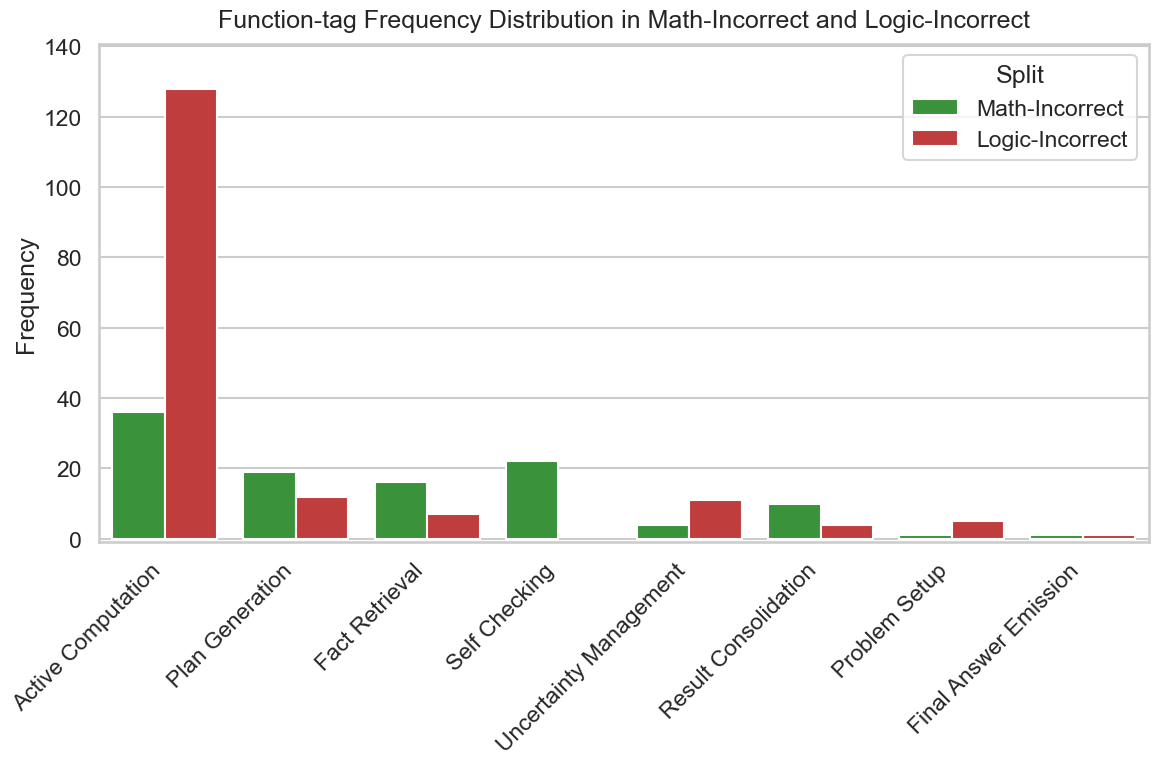

Saved figure to: d:\Files\UW-M\26_1_spring\CS639\prj\proposal_math+logic\Function-tag_frequency_distribution_Math-Logic-Incorrect.png


In [5]:
sns.set_theme(style="whitegrid", context="talk")

hue_order = ["Math-Incorrect", "Logic-Incorrect"]
palette = {
    "Math-Incorrect": "#2ca02c",
    "Logic-Incorrect": "#d62728",
}

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(
    data=freq_counts,
    x="Category",
    y="Count",
    hue="Split",
    order=category_order,
    hue_order=hue_order,
    palette=palette,
    ax=ax,
)

ax.set_title("Function-tag Frequency Distribution in Math-Incorrect and Logic-Incorrect", pad=12)
ax.set_ylabel("Frequency")
ax.set_xlabel("")
y_top = max(1.0, float(freq_counts["Count"].max()) * 1.1)
ax.set_ylim(-1, y_top)
for tick in ax.get_xticklabels():
    tick.set_rotation(45)
    tick.set_ha("right")

ax.legend(title="Split", loc="upper right", frameon=True)
plt.tight_layout()
OUTPUT_FREQ_FIG_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_FREQ_FIG_PATH, dpi=300)
plt.show()

print(f"Saved figure to: {OUTPUT_FREQ_FIG_PATH}")


# Function-tag Frequency Distribution (Math-Correct + Logic-Correct)

This section redraws and combines the function-tag frequency distributions for Math-Correct and Logic-Correct in one figure.

In [6]:
INCORRECT_ANALYSIS_PATHS = {
    "Math-Correct": DATA_ROOT / "math" / "problem_0" / "im_CF_kl" / "correct_base_solution" / "analysis_results.json",
    "Logic-Correct": DATA_ROOT / "logic" / "problem_0" / "im_CF_kl" / "correct_base_solution" / "analysis_results.json",
}

OUTPUT_FREQ_FIG_PATH = DATA_ROOT / "Function-tag_frequency_distribution_Math-Logic-Correct.png"


def load_tag_records(analysis_path: Path, split_name: str) -> list[dict]:
    payload = json.loads(analysis_path.read_text(encoding="utf-8"))
    if isinstance(payload, dict):
        payload = [payload]

    records = []
    for problem_result in payload:
        for chunk in problem_result.get("labeled_chunks", []):
            for raw_tag in (chunk.get("function_tags") or []):
                tag = str(raw_tag).strip()
                if not tag or tag.lower() == "unknown":
                    continue
                records.append({
                    "Split": split_name,
                    "Category": _to_display_tag(tag),
                })
    return records


tag_records = []
for split_name, analysis_path in INCORRECT_ANALYSIS_PATHS.items():
    if not analysis_path.exists():
        raise FileNotFoundError(f"Missing file: {analysis_path}")
    tag_records.extend(load_tag_records(analysis_path, split_name))

tag_df = pd.DataFrame(tag_records)
if tag_df.empty:
    raise ValueError("No valid function-tag records found.")

freq_counts = (
    tag_df.groupby(["Split", "Category"])
          .size()
          .reset_index(name="Count")
)

category_order = (
    freq_counts.groupby("Category", as_index=False)["Count"]
               .sum()
               .sort_values("Count", ascending=False)["Category"]
               .tolist()
)

freq_counts.pivot(index="Category", columns="Split", values="Count").fillna(0).astype(int)


Split,Logic-Correct,Math-Correct
Category,,
Active Computation,152,89
Fact Retrieval,31,7
Final Answer Emission,0,1
Plan Generation,19,15
Problem Setup,11,3
Result Consolidation,30,1
Self Checking,6,5
Uncertainty Management,106,27


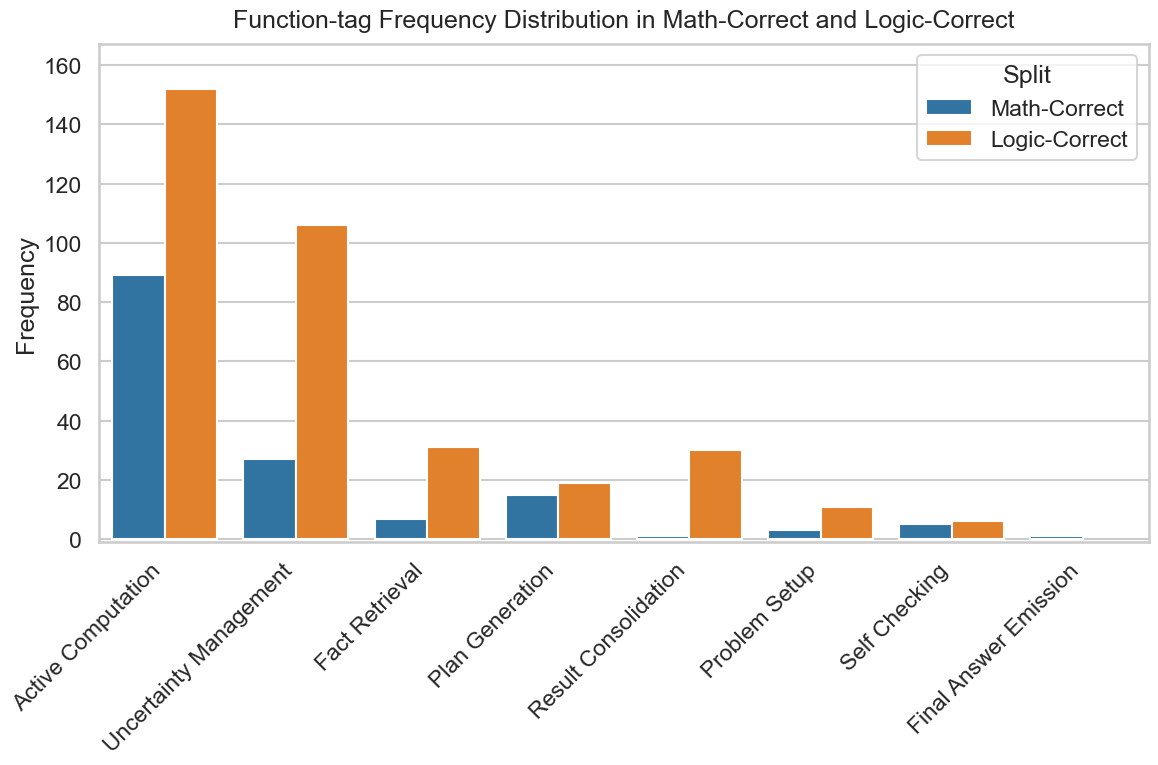

Saved figure to: d:\Files\UW-M\26_1_spring\CS639\prj\proposal_math+logic\Function-tag_frequency_distribution_Math-Logic-Correct.png


In [7]:
sns.set_theme(style="whitegrid", context="talk")

hue_order = ["Math-Correct", "Logic-Correct"]
palette = {
    "Math-Correct": "#1f77b4",
    "Logic-Correct": "#ff7f0e",
}

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(
    data=freq_counts,
    x="Category",
    y="Count",
    hue="Split",
    order=category_order,
    hue_order=hue_order,
    palette=palette,
    ax=ax,
)

ax.set_title("Function-tag Frequency Distribution in Math-Correct and Logic-Correct", pad=12)
ax.set_ylabel("Frequency")
ax.set_xlabel("")
y_top = max(1.0, float(freq_counts["Count"].max()) * 1.1)
ax.set_ylim(-1, y_top)
for tick in ax.get_xticklabels():
    tick.set_rotation(45)
    tick.set_ha("right")

ax.legend(title="Split", loc="upper right", frameon=True)
plt.tight_layout()
OUTPUT_FREQ_FIG_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_FREQ_FIG_PATH, dpi=300)
plt.show()

print(f"Saved figure to: {OUTPUT_FREQ_FIG_PATH}")


# Chunk-level Rollout Accuracy by Position (Math-Correct + Logic-Correct)

This section combines the chunk-level rollout accuracy-by-position curves from Math-Correct and Logic-Correct into one figure.

In [8]:
CORRECT_ACCURACY_PATHS = {
    "Math-Correct": DATA_ROOT / "math" / "problem_0" / "im_CF_kl" / "correct_base_solution" / "analysis_results.json",
    "Logic-Correct": DATA_ROOT / "logic" / "problem_0" / "im_CF_kl" / "correct_base_solution" / "analysis_results.json",
}

MAX_CHUNK_POSITION = 100
OUTPUT_ACC_POS_FIG_PATH = DATA_ROOT / "Chunk-level_rollout_accuracy_by_position_Math-Logic-Correct.png"


def load_chunk_accuracy_records(analysis_path: Path, split_name: str, max_position: int = 100) -> list[dict]:
    payload = json.loads(analysis_path.read_text(encoding="utf-8"))
    if isinstance(payload, dict):
        payload = [payload]

    records = []
    for problem_result in payload:
        for chunk in problem_result.get("labeled_chunks", []):
            chunk_idx = chunk.get("chunk_idx")
            accuracy = chunk.get("accuracy")
            if chunk_idx is None or accuracy is None:
                continue
            if int(chunk_idx) > max_position:
                continue

            records.append({
                "Split": split_name,
                "Chunk Index": int(chunk_idx),
                "Accuracy": float(accuracy),
            })
    return records


accuracy_records = []
for split_name, analysis_path in CORRECT_ACCURACY_PATHS.items():
    if not analysis_path.exists():
        raise FileNotFoundError(f"Missing file: {analysis_path}")
    accuracy_records.extend(
        load_chunk_accuracy_records(analysis_path, split_name, max_position=MAX_CHUNK_POSITION)
    )

acc_df = pd.DataFrame(accuracy_records)
if acc_df.empty:
    raise ValueError("No chunk-level accuracy data found.")

acc_df = acc_df.sort_values(["Split", "Chunk Index"]).reset_index(drop=True)

acc_df.groupby("Split")["Accuracy"].agg(["count", "mean", "min", "max"]).round(3)


,count,mean,min,max
Split,,,,
Logic-Correct,101,0.724,0.40,1.0
Math-Correct,101,0.925,0.45,1.0


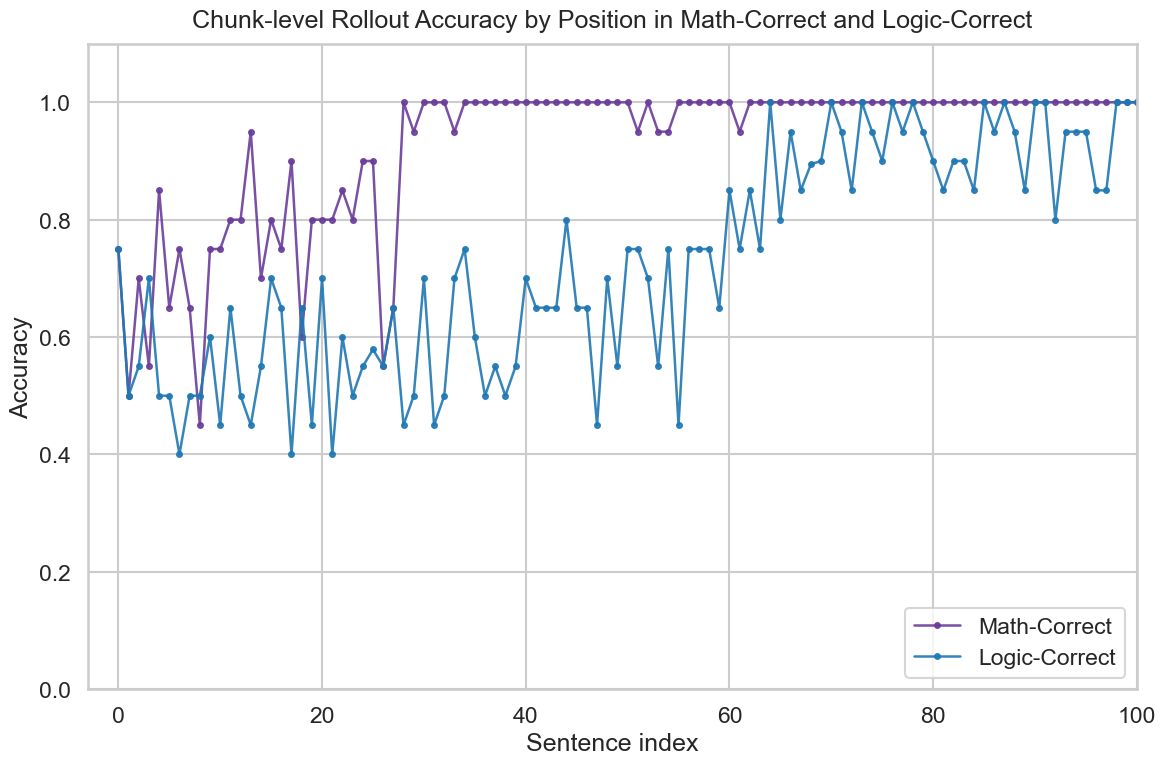

Saved figure to: d:\Files\UW-M\26_1_spring\CS639\prj\proposal_math+logic\Chunk-level_rollout_accuracy_by_position_Math-Logic-Correct.png


In [9]:
sns.set_theme(style="whitegrid", context="talk")

split_order = ["Math-Correct", "Logic-Correct"]
palette = {
    "Math-Correct": "#6a3d9a",
    "Logic-Correct": "#1f78b4",
}

fig, ax = plt.subplots(figsize=(12, 8))
for split_name in split_order:
    split_df = acc_df[acc_df["Split"] == split_name].sort_values("Chunk Index")
    if split_df.empty:
        continue

    ax.plot(
        split_df["Chunk Index"],
        split_df["Accuracy"],
        marker="o",
        markersize=4,
        linewidth=1.8,
        alpha=0.9,
        color=palette[split_name],
        label=split_name,
    )

ax.set_title("Chunk-level Rollout Accuracy by Position in Math-Correct and Logic-Correct", pad=12)
ax.set_xlabel("Sentence index")
ax.set_ylabel("Accuracy")
ax.set_xlim(-3, MAX_CHUNK_POSITION)
ax.set_ylim(0, 1.1)
ax.legend(loc="lower right", frameon=True)

plt.tight_layout()
OUTPUT_ACC_POS_FIG_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_ACC_POS_FIG_PATH, dpi=300)
plt.show()

print(f"Saved figure to: {OUTPUT_ACC_POS_FIG_PATH}")


# Variance of CF-KL by Function Tag (Math-Correct + Logic-Correct)

This section combines the CF-KL variance-by-function-tag results from Math-Correct and Logic-Correct into one figure.

In [10]:
from collections import defaultdict

VARIANCE_ANALYSIS_PATHS = {
    "Math-Correct": DATA_ROOT / "math" / "problem_0" / "im_CF_kl" / "correct_base_solution" / "analysis_results.json",
    "Logic-Correct": DATA_ROOT / "logic" / "problem_0" / "im_CF_kl" / "correct_base_solution" / "analysis_results.json",
}

MIN_COUNT_PER_TAG = 5
OUTPUT_VAR_FIG_PATH = DATA_ROOT / "Variance_of_CF-KL_by_function_tag_Math-Logic-Correct.png"


def compute_tag_variance_records(analysis_path: Path, split_name: str, min_count: int = 5) -> list[dict]:
    payload = json.loads(analysis_path.read_text(encoding="utf-8"))
    if isinstance(payload, dict):
        payload = [payload]

    tag_values: dict[str, list[float]] = defaultdict(list)
    for problem_result in payload:
        for chunk in problem_result.get("labeled_chunks", []):
            cf_kl = float(chunk.get("counterfactual_importance_kl", 0.0))
            for raw_tag in (chunk.get("function_tags") or []):
                tag = str(raw_tag).strip()
                if not tag or tag.lower() == "unknown":
                    continue
                tag_values[_to_display_tag(tag)].append(cf_kl)

    records = []
    for tag, values in tag_values.items():
        if len(values) < min_count:
            continue
        records.append({
            "Split": split_name,
            "Function Tag": tag,
            "Variance": float(np.var(values)),
            "Count": int(len(values)),
            "Mean": float(np.mean(values)),
        })
    return records


variance_records = []
for split_name, analysis_path in VARIANCE_ANALYSIS_PATHS.items():
    if not analysis_path.exists():
        raise FileNotFoundError(f"Missing file: {analysis_path}")
    variance_records.extend(
        compute_tag_variance_records(analysis_path, split_name, min_count=MIN_COUNT_PER_TAG)
    )

variance_df = pd.DataFrame(variance_records)
if variance_df.empty:
    raise ValueError("No variance records found.")

tag_order = (
    variance_df.groupby("Function Tag", as_index=False)["Variance"]
               .max()
               .sort_values("Variance", ascending=False)["Function Tag"]
               .tolist()
)

variance_df.sort_values(["Split", "Variance"], ascending=[True, False])


,Split,Function Tag,Variance,Count,Mean
6,Logic-Correct,Plan Generation,0.325661,19,0.322404
8,Logic-Correct,Active Computation,0.309940,152,0.169528
9,Logic-Correct,Uncertainty Management,0.257715,106,0.219401
11,Logic-Correct,Result Consolidation,0.157947,30,0.185694
7,Logic-Correct,Fact Retrieval,0.146227,31,0.098165
10,Logic-Correct,Self Checking,0.009899,6,0.082795
5,Logic-Correct,Problem Setup,0.008989,11,0.056624
0,Math-Correct,Plan Generation,1.223927,15,0.714814
2,Math-Correct,Active Computation,0.749494,89,0.155892
1,Math-Correct,Fact Retrieval,0.124767,7,0.193756


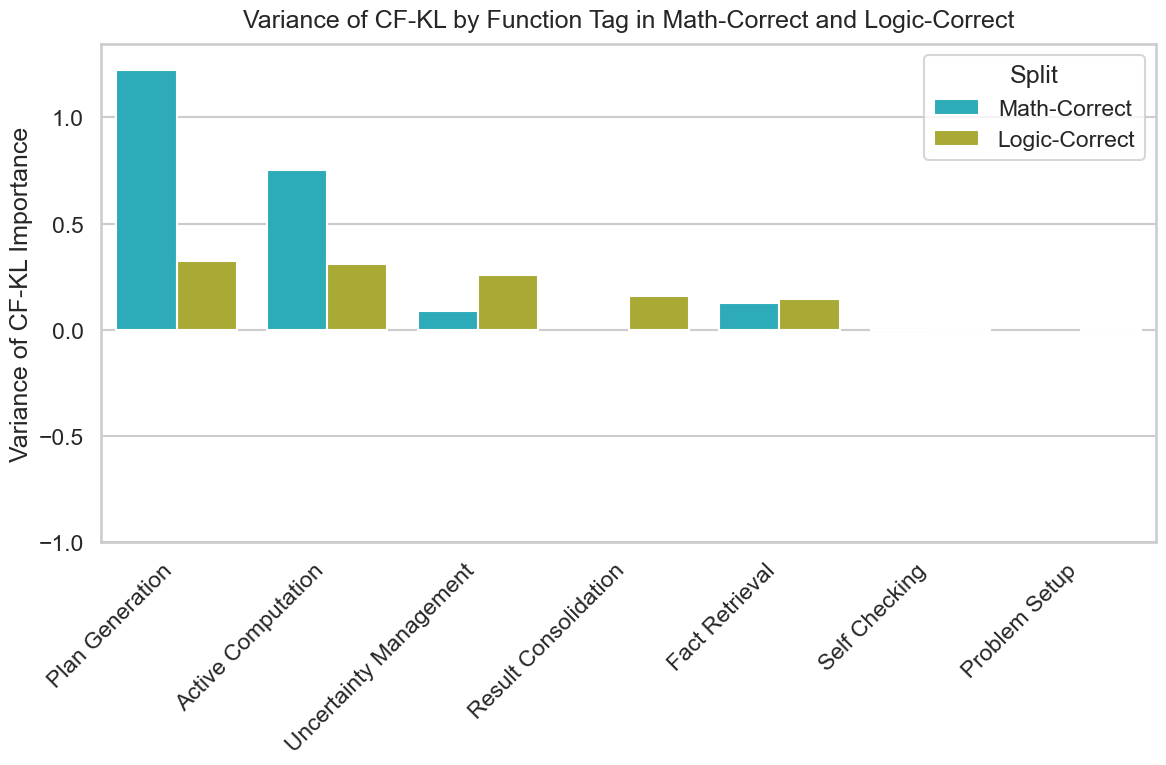

Saved figure to: d:\Files\UW-M\26_1_spring\CS639\prj\proposal_math+logic\Variance_of_CF-KL_by_function_tag_Math-Logic-Correct.png


In [ ]:
sns.set_theme(style="whitegrid", context="talk")

split_order = ["Math-Correct", "Logic-Correct"]
palette = {
    "Math-Correct": "#17becf",
    "Logic-Correct": "#bcbd22",
}

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(
    data=variance_df,
    x="Function Tag",
    y="Variance",
    hue="Split",
    order=tag_order,
    hue_order=split_order,
    palette=palette,
    ax=ax,
)

ax.set_title("Variance of CF-KL by Function Tag in Math-Correct and Logic-Correct", pad=12)
ax.set_xlabel("")
ax.set_ylabel("Variance of CF-KL Importance")
y_top = max(1.0, float(variance_df["Variance"].max()) * 1.1)
ax.set_ylim(0, y_top)
for tick in ax.get_xticklabels():
    tick.set_rotation(45)
    tick.set_ha("right")

ax.legend(title="Split", loc="upper right", frameon=True)
plt.tight_layout()
OUTPUT_VAR_FIG_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_VAR_FIG_PATH, dpi=300)
plt.show()

print(f"Saved figure to: {OUTPUT_VAR_FIG_PATH}")
